In [21]:
# Posted on https://github.com/peterdsharpe/AeroSandbox/issues/158

import aerosandbox as asb
import aerosandbox.numpy as np

# define airplane params

wing_airfoil = asb.Airfoil("clarky")
tail_airfoil = asb.Airfoil("clarky")

main_half_span = 0.6
main_chord = 0.127

tail_half_span = 0.25
tail_chord = 0.127

tail_offset = 0.6

opti = asb.Opti()

main_twist = opti.variable(init_guess=2)
tail_twist = opti.variable(init_guess=-2)
xyz_ref_x = opti.variable(init_guess=0.25)

# define airplane

airplane = asb.Airplane(
    name="test",
    wings=[
        asb.Wing(
            name="Main",
            symmetric=True,
            xsecs=[
                asb.WingXSec(
                    xyz_le=[0, 0, 0],
                    chord=main_chord,
                    airfoil=wing_airfoil,
                    twist=main_twist,
                ),
                asb.WingXSec(
                    xyz_le=[0.00, main_half_span, 0],
                    chord=main_chord,
                    airfoil=wing_airfoil,
                    twist=main_twist,
                ),
            ],
        ),
        asb.Wing(
            name="Tail",
            symmetric=True,
            xsecs=[
                asb.WingXSec(
                    xyz_le=[0, 0, 0],
                    chord=tail_chord,
                    twist=tail_twist,
                    airfoil=tail_airfoil,
                ),
                asb.WingXSec(
                    xyz_le=[0, tail_half_span, 0],
                    chord=tail_chord,
                    twist=tail_twist,
                    airfoil=tail_airfoil,
                ),
            ],
        ).translate([tail_offset, 0, 0]),
    ],
)

# run AeroBuildup (includes profile/parasite drag unlike VLM)
aerobuildup = asb.AeroBuildup(
    airplane=airplane,
    op_point=asb.OperatingPoint(
        velocity=20,
    ),
    xyz_ref=[xyz_ref_x, 0, 0],
)

aero = aerobuildup.run_with_stability_derivatives()

# setup constraints and objective function

L_over_D = aero["CL"] / aero["CD"]

opti.subject_to(
    [
        aero["Cm"] == 0,
        aero["Cma"] <= -1e-3,
        xyz_ref_x >= -0.5,
        xyz_ref_x <= 1.5,
    ]
)

opti.minimize(-L_over_D)

sol = opti.solve()

# print results

print(f"Twist for max L/D: {sol(main_twist):.3f} deg")
print(f"Tail twist to zero moments: {sol(tail_twist):.3f} deg")
print(f"L/D at optimum: {sol(L_over_D):.3f}")
print(f"Cma at optimum: {sol(aero['Cma']):.5f} 1/rad")
print(f"xyz_ref_x at optimum: {sol(xyz_ref_x):.4f} m")




This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        3
Number of nonzeros in inequality constraint Jacobian.:        5
Number of nonzeros in Lagrangian Hessian.............:        5

Total number of variables............................:        3
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:        3
        inequality constraints with only lower bounds:        1
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        2

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -1.8031870e+01 2.92e+00 9.25e-01   0.0 0.00e+00    -  0.00e+00 0.00e+00 

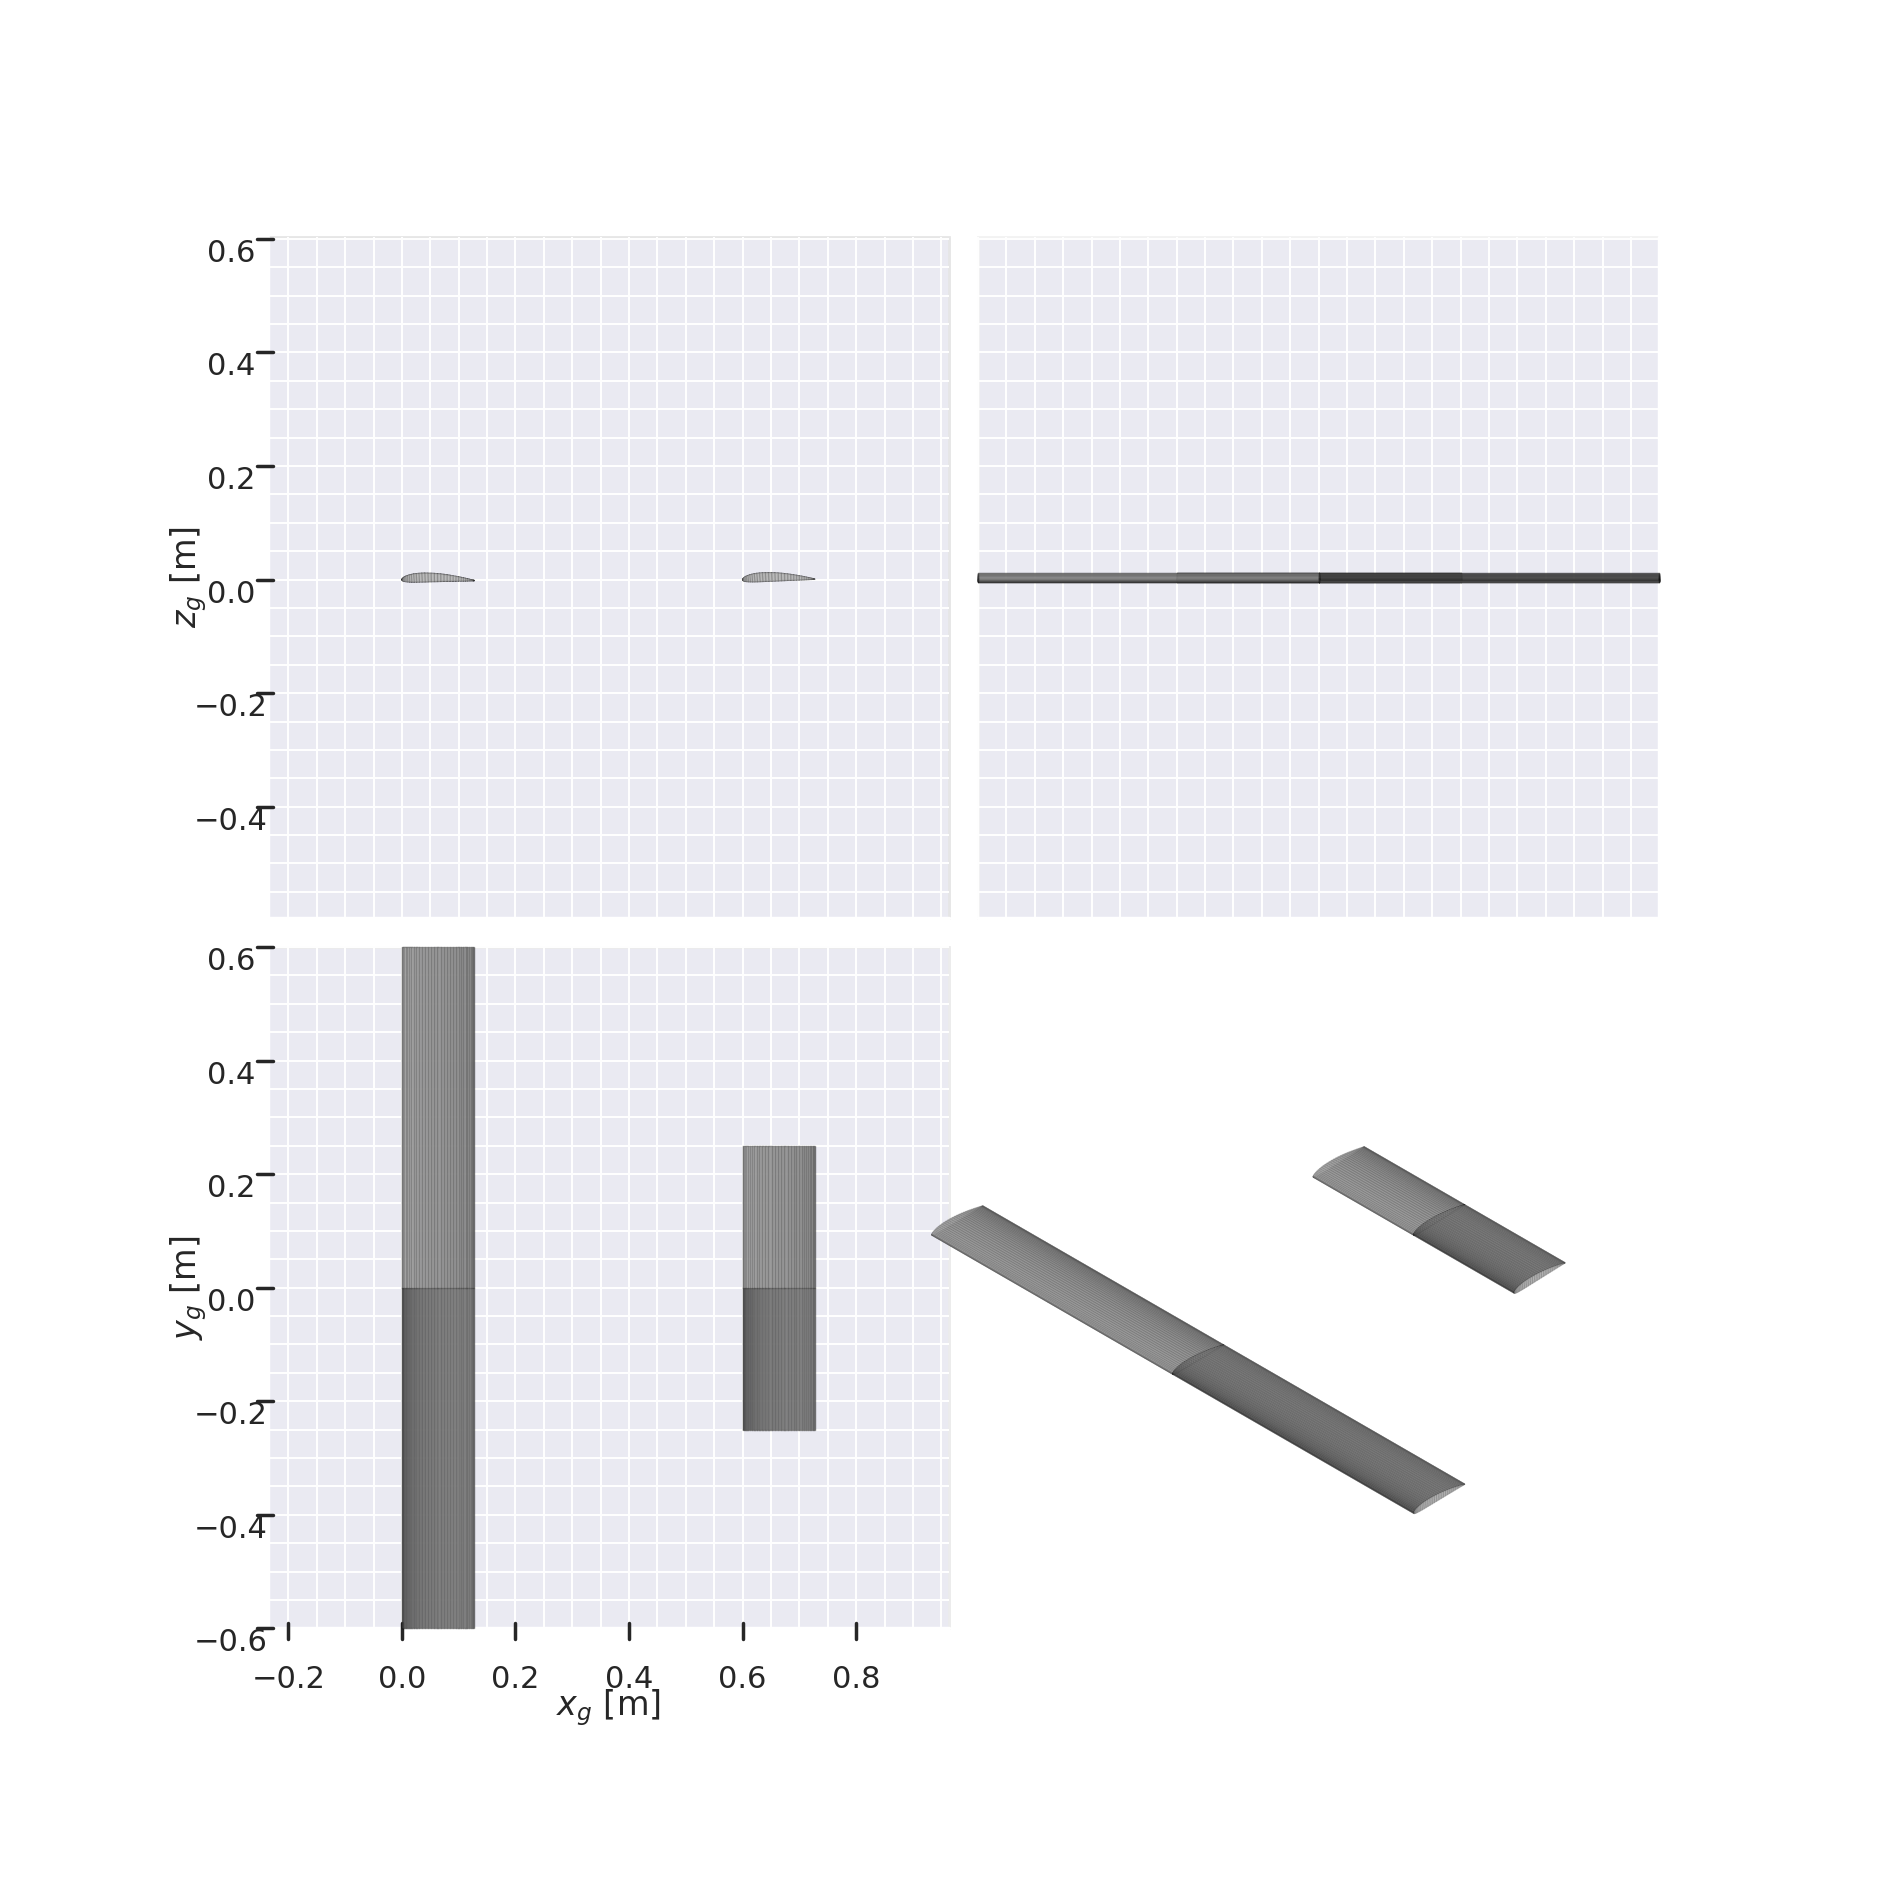

array([[<Axes3D: zlabel='$z_g$ [m]'>, <Axes3D: >],
       [<Axes3D: xlabel='$x_g$ [m]', ylabel='$y_g$ [m]'>, <Axes3D: >]],
      dtype=object)

In [22]:
airplane = sol(airplane)
airplane.draw_three_view()

In [23]:
# Side-by-side comparison:
# 1) free xyz_ref_x with fixed front wing x
# 2) fixed xyz_ref_x with free front wing x

def optimize_incidence_case(free_xyz_ref_x: bool, fixed_xyz_ref_x: float = 0.20):
    opti = asb.Opti()

    main_twist = opti.variable(init_guess=2)
    tail_twist = opti.variable(init_guess=-2)

    if free_xyz_ref_x:
        xyz_ref_x = opti.variable(init_guess=fixed_xyz_ref_x)
        front_wing_x = 0.0
    else:
        xyz_ref_x = fixed_xyz_ref_x
        front_wing_x = opti.variable(init_guess=0.0)

    airplane_case = asb.Airplane(
        name="test",
        wings=[
            asb.Wing(
                name="Main",
                symmetric=True,
                xsecs=[
                    asb.WingXSec(
                        xyz_le=[front_wing_x, 0, 0],
                        chord=main_chord,
                        airfoil=wing_airfoil,
                        twist=main_twist,
                    ),
                    asb.WingXSec(
                        xyz_le=[front_wing_x, main_half_span, 0],
                        chord=main_chord,
                        airfoil=wing_airfoil,
                        twist=main_twist,
                    ),
                ],
            ),
            asb.Wing(
                name="Tail",
                symmetric=True,
                xsecs=[
                    asb.WingXSec(
                        xyz_le=[0, 0, 0],
                        chord=tail_chord,
                        twist=tail_twist,
                        airfoil=tail_airfoil,
                    ),
                    asb.WingXSec(
                        xyz_le=[0, tail_half_span, 0],
                        chord=tail_chord,
                        twist=tail_twist,
                        airfoil=tail_airfoil,
                    ),
                ],
            ).translate([tail_offset, 0, 0]),
        ],
    )

    aerobuildup_case = asb.AeroBuildup(
        airplane=airplane_case,
        op_point=asb.OperatingPoint(velocity=20),
        xyz_ref=[xyz_ref_x, 0, 0],
    )

    aero_case = aerobuildup_case.run_with_stability_derivatives()
    l_over_d_case = aero_case["CL"] / aero_case["CD"]

    constraints = [
        aero_case["Cm"] == 0,
        aero_case["Cma"] <= -1e-3,
    ]
    if free_xyz_ref_x:
        constraints += [xyz_ref_x >= -0.5, xyz_ref_x <= 1.5]
    else:
        constraints += [front_wing_x >= -0.3, front_wing_x <= 0.3]

    opti.subject_to(constraints)
    opti.minimize(-l_over_d_case)

    sol_case = opti.solve()

    return {
        "main_twist_deg": float(sol_case(main_twist)),
        "tail_twist_deg": float(sol_case(tail_twist)),
        "L_over_D": float(sol_case(l_over_d_case)),
        "Cm": float(sol_case(aero_case["Cm"])),
        "Cma_1_per_rad": float(sol_case(aero_case["Cma"])),
        "xyz_ref_x_m": float(sol_case(xyz_ref_x)) if free_xyz_ref_x else float(fixed_xyz_ref_x),
        "front_wing_x_m": float(front_wing_x) if free_xyz_ref_x else float(sol_case(front_wing_x)),
    }


case_a = optimize_incidence_case(free_xyz_ref_x=True, fixed_xyz_ref_x=0.20)
case_b = optimize_incidence_case(free_xyz_ref_x=False, fixed_xyz_ref_x=0.20)

print("Comparison at fixed speed = 20 m/s")
print("-" * 106)
print(f"{'Metric':<20} {'Case A: free xyz_ref_x':>38} {'Case B: free front wing x':>42}")
print("-" * 106)
for key, label in [
    ("main_twist_deg", "main_twist [deg]"),
    ("tail_twist_deg", "tail_twist [deg]"),
    ("L_over_D", "L/D [-]"),
    ("Cm", "Cm [-]"),
    ("Cma_1_per_rad", "Cma [1/rad]"),
    ("xyz_ref_x_m", "xyz_ref_x [m]"),
    ("front_wing_x_m", "front_wing_x [m]"),
]:
    print(f"{label:<20} {case_a[key]:>38.6f} {case_b[key]:>42.6f}")



This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        3
Number of nonzeros in inequality constraint Jacobian.:        5
Number of nonzeros in Lagrangian Hessian.............:        5

Total number of variables............................:        3
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:        3
        inequality constraints with only lower bounds:        1
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        2

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -1.8031870e+01 3.88e-01 8.86e-01   0.0 0.00e+00    -  0.00e+00 0.00e+00 